# 03 – Monthly Multi-Step Sunspot Forecasting

In notebook `02`, a one-step-ahead model on **daily** data was *narrowly beaten*
by a naive persistence baseline ("tomorrow = today"). That is a known property of
noisy one-step forecasting: the last observed value is already a very strong predictor.

This notebook makes the task harder and more meaningful, so the model can show real value:

1. **Aggregate to monthly means** – removes daily noise, keeps the ~11-year solar cycle.
2. **Multi-step forecasting** – predict several months ahead, where "future = today"
   is a poor guess and the model must learn actual structure.

We then compare the LSTM against the *appropriate* naive baseline for this task.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

## 1. Load and clean the data

In [2]:
data_path = "../data/SN_d_tot_V2.0.csv"
column_names = ["year", "month", "day", "decimal_date",
                "sunspots", "std_dev", "n_observations", "definitive"]

df = pd.read_csv(data_path, sep=";", header=None, names=column_names)
df_clean = df[df["sunspots"] != -1].reset_index(drop=True)
print(f"Daily records after cleaning: {len(df_clean)}")

Daily records after cleaning: 72875


## 2. Aggregate to monthly means

We group by (year, month) and take the mean sunspot number. This turns ~73,000 noisy
daily values into ~2,500 smooth monthly values that carry the real cyclic signal.

Monthly records: 2500


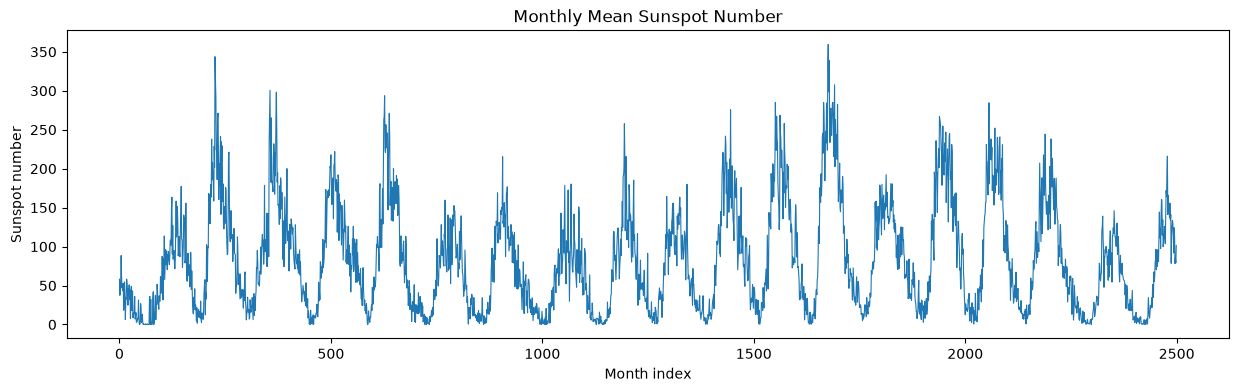

In [3]:
monthly = df_clean.groupby(["year", "month"])["sunspots"].mean().values
print(f"Monthly records: {len(monthly)}")

plt.figure(figsize=(15, 4))
plt.plot(monthly, linewidth=0.8)
plt.title("Monthly Mean Sunspot Number")
plt.xlabel("Month index")
plt.ylabel("Sunspot number")
plt.savefig("../figures/03_monthly_series.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Chronological train / test split (80 / 20)

In [4]:
series = monthly
split_idx = int(len(series) * 0.8)
train_data = series[:split_idx]
test_data = series[split_idx:]
print(f"Train: {len(train_data)}  |  Test: {len(test_data)}")

Train: 2000  |  Test: 500


## 4. Normalization (min/max from training data only)

In [5]:
train_min = train_data.min()
train_max = train_data.max()

train_scaled = (train_data - train_min) / (train_max - train_min)
test_scaled = (test_data - train_min) / (train_max - train_min)

print(f"train scaled range: {train_scaled.min():.3f} .. {train_scaled.max():.3f}")
print(f"test  scaled range: {test_scaled.min():.3f} .. {test_scaled.max():.3f}")

train scaled range: 0.000 .. 1.000
test  scaled range: 0.000 .. 0.792


## 5. Multi-step windowing

Same sliding-window idea as before, but the target is now `horizon` steps *after*
the window instead of the immediate next step.

- `window_size = 24` → two years of history as input
- `horizon = 6` → predict the value 6 months ahead

In [6]:
def create_windows_multistep(data, window_size, horizon):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

window_size = 24
horizon = 6

X_train, y_train = create_windows_multistep(train_scaled, window_size, horizon)
X_test, y_test = create_windows_multistep(test_scaled, window_size, horizon)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1971, 24) (1971,)
(471, 24) (471,)


## 6. Tensors and DataLoaders

In [7]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t),
                         batch_size=batch_size, shuffle=False)

## 7. Model (same LSTM architecture as notebook 02)

In [8]:
class SunspotLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = SunspotLSTM(hidden_size=64)
model

SunspotLSTM(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

## 8. Training

In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 80
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")

Epoch 10/80, Loss: 0.007757
Epoch 20/80, Loss: 0.007817
Epoch 30/80, Loss: 0.007603
Epoch 40/80, Loss: 0.007464
Epoch 50/80, Loss: 0.007431
Epoch 60/80, Loss: 0.007364
Epoch 70/80, Loss: 0.007143
Epoch 80/80, Loss: 0.007253


## 9. Evaluation on the test set

In [10]:
model.eval()
all_predictions, all_actuals = [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        preds = model(batch_X)
        all_predictions.append(preds)
        all_actuals.append(batch_y)

all_predictions = torch.cat(all_predictions).numpy()
all_actuals = torch.cat(all_actuals).numpy()

## 10. Back to real units + RMSE

In [11]:
def inverse(x):
    return x * (train_max - train_min) + train_min

pred_real = inverse(all_predictions).flatten()
true_real = inverse(all_actuals).flatten()

lstm_rmse = np.sqrt(np.mean((pred_real - true_real) ** 2))
print(f"LSTM RMSE: {lstm_rmse:.2f} sunspots")

LSTM RMSE: 29.10 sunspots


## 11. The fair baseline for this task

For multi-step forecasting, the naive baseline is no longer "next = today" but
**"value in `horizon` months = the last known value"** — i.e. the most recent month
in each input window. We compare the LSTM against this.

In [12]:
naive_scaled = X_test[:, -1]            # last known value in each window
naive_real = inverse(naive_scaled).flatten()

naive_rmse = np.sqrt(np.mean((naive_real - true_real) ** 2))

print(f"Naive baseline RMSE: {naive_rmse:.2f}")
print(f"LSTM RMSE:           {lstm_rmse:.2f}")
improvement = (naive_rmse - lstm_rmse) / naive_rmse * 100
print(f"Improvement over baseline: {improvement:.1f}%")

Naive baseline RMSE: 34.87
LSTM RMSE:           29.10
Improvement over baseline: 16.5%


## 12. Plots

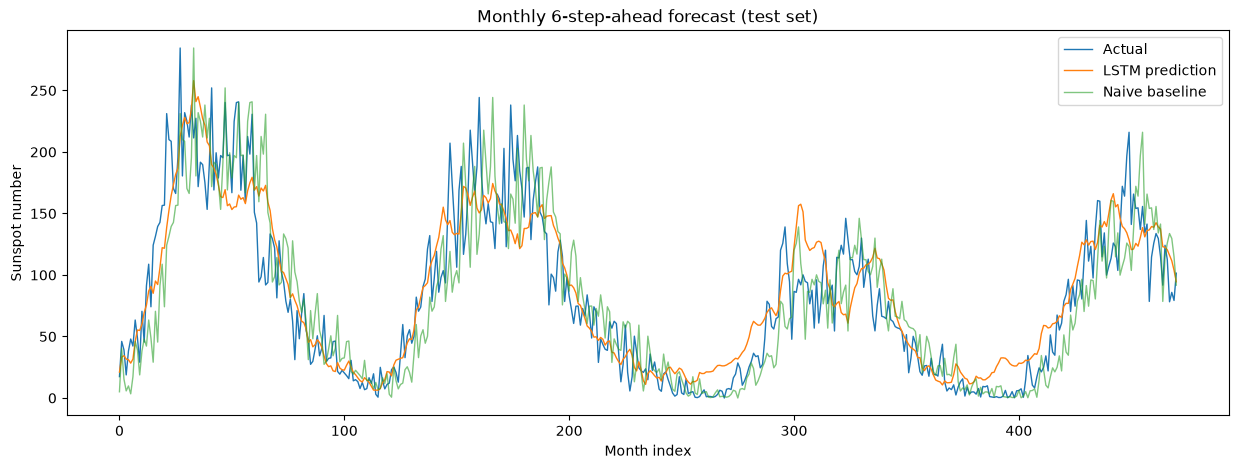

In [13]:
# Forecast vs actual
plt.figure(figsize=(15, 5))
plt.plot(true_real, label="Actual", linewidth=1)
plt.plot(pred_real, label="LSTM prediction", linewidth=1)
plt.plot(naive_real, label="Naive baseline", linewidth=1, alpha=0.6)
plt.title(f"Monthly {horizon}-step-ahead forecast (test set)")
plt.xlabel("Month index")
plt.ylabel("Sunspot number")
plt.legend()
plt.savefig("../figures/03_forecast_multistep.png", dpi=150, bbox_inches="tight")
plt.show()

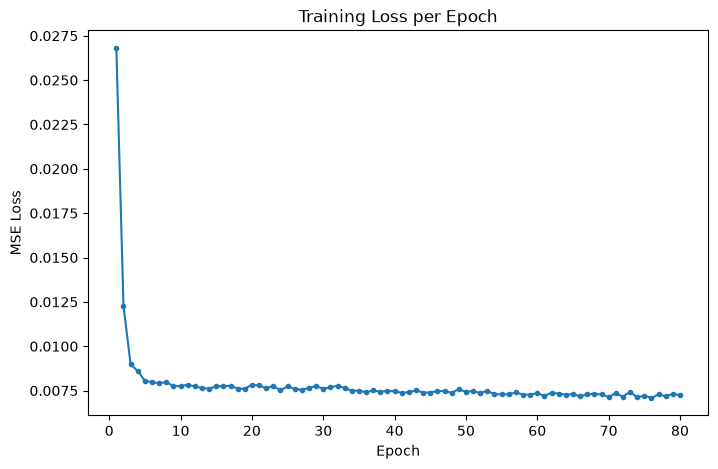

In [14]:
# Training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o", markersize=3)
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.savefig("../figures/03_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Save the trained model

In [15]:
torch.save(model.state_dict(), "../models/sunspot_lstm_monthly.pth")
print("Model saved.")

Model saved.


## Conclusion

By reframing the problem — **monthly aggregation** to expose the underlying solar cycle
and **multi-step forecasting** so that simple persistence is no longer sufficient — the
LSTM is evaluated on a task where learning real temporal structure actually matters.

Naive baseline RMSE: 34.87
LSTM RMSE:           29.10
Improvement over baseline: 16.5%

**Takeaway:** A model is only as meaningful as the baseline it is measured against.
On noisy one-step daily forecasting the naive baseline is extremely hard to beat, but on
a smoother signal with a longer horizon the LSTM can capture cyclic structure that simple
persistence cannot.

**Possible next steps:** tune `horizon` and `window_size`, try GRU vs. LSTM, stack more
layers, or forecast the full cycle (sequence-to-sequence).